# Tuần 07 — Thực hành k-Means: 3 bài

Demo `03_Demo-kMeans.ipynb` gom cụm bằng tay trên dữ liệu giả 2 chiều.

File này có **3 bài**. Mỗi bài là một bộ dữ liệu thật trên Kaggle. Cả 3 bài đều làm. Dùng `sklearn.cluster.KMeans`.

Clustering không chia train/test và không có nhãn để học. `StandardScaler` fit trên toàn bộ bảng feature. Không đưa cột ID hay tên vào khoảng cách.

Tải 3 file vào `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |

Ba bộ này cũng được dùng ở `09_TH-DBSCAN.ipynb`, để so sánh hai cách gom cụm trên cùng dữ liệu.


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)


## Phần chung

Elbow: với mỗi `K` từ 1 đến `k_max`, fit `KMeans` (`n_init=10`, `random_state=3000`), lưu `inertia_`, rồi vẽ. Chỗ khuỷu tay là `K` nên thử.

Sau khi có nhãn, bảng trung bình theo cụm giúp đọc ý nghĩa từng nhóm.


In [2]:
def ve_elbow(X_scaled, k_max=10):
    ks = list(range(1, k_max + 1))
    inertias = []
    for k in ks:
        # TODO: fit KMeans với n_clusters=k, n_init=10, random_state=3000
        # lưu model.inertia_ vào inertias
        model = KMeans(n_clusters=k, n_init=10, random_state=3000).fit(X_scaled)
        inertias.append(model.inertia_)
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker='o')
    plt.xlabel('K')
    plt.ylabel('inertia')
    plt.grid(True)
    plt.show()
    return ks, inertias


def bang_trung_binh(df_goc, labels, cot_so):
    tam = df_goc[cot_so].copy()
    tam['cum'] = labels
    return tam.groupby('cum').mean().round(2)

---

# Bài 1 — Khách hàng trung tâm thương mại

Nguồn: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

200 khách. Cột: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

Bài này chỉ dùng **thu nhập** và **điểm chi tiêu**. Bỏ `CustomerID`. Không đưa `Gender` vào khoảng cách. Có thể để `Age` sang một lần chạy riêng nếu còn thời gian.

Chuẩn hóa hai cột, vẽ elbow, chọn `K`, tô màu scatter theo cụm. Dấu `x` là tâm cụm tính trên **số gốc** (trung bình thu nhập và điểm chi tiêu của các điểm trong cụm), để đọc được đơn vị thật.


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


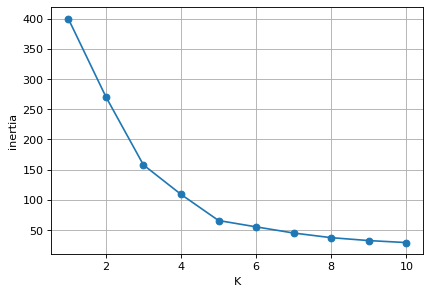

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [399.99999999999994, 270.66820496844673, 157.70400815035939, 108.92131661364358, 65.56840815571681, 55.103778121150555, 44.86628627232252, 37.1817578268213, 32.37724377444034, 29.076176851244288])

In [3]:
mall = pd.read_csv('data/Mall_Customers.csv')
print(mall.head())
print(mall.shape)

cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_elbow(X_scaled)


     Annual Income (k$)  Spending Score (1-100)
cum                                            
0                 55.30                   49.52
1                 88.20                   17.11
2                 26.30                   20.91
3                 86.54                   82.13
4                 25.73                   79.36
số điểm mỗi cụm: (array([0, 1, 2, 3, 4], dtype=int32), array([81, 35, 23, 39, 22]))


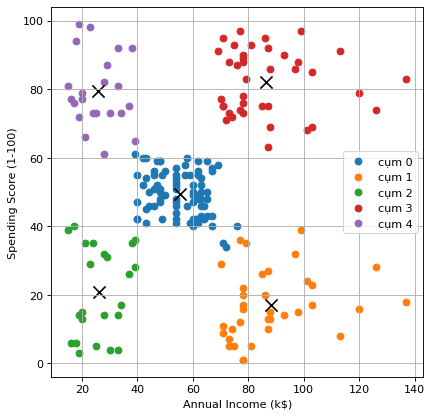

In [4]:
# TODO: chọn K từ elbow
K = 5
model = KMeans(n_clusters=K, n_init=10, random_state=3000)
labels = model.fit_predict(X_scaled)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')
    plt.scatter(pts[:, 0].mean(), pts[:, 1].mean(), c='black', marker='x', s=120)
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

print(bang_trung_binh(mall, labels, cot))
print('số điểm mỗi cụm:', np.unique(labels, return_counts=True))

inertia khi có Age: [600.0, 389.4, 295.5, 205.2, 168.2, 133.9, 117.1, 103.8, 92.0, 81.8]
K=4: silhouette 2 cột = 0.494, silhouette 3 cột (có Age) = 0.404
K=5: silhouette 2 cột = 0.555, silhouette 3 cột (có Age) = 0.417
K=6: silhouette 2 cột = 0.538, silhouette 3 cột (có Age) = 0.427


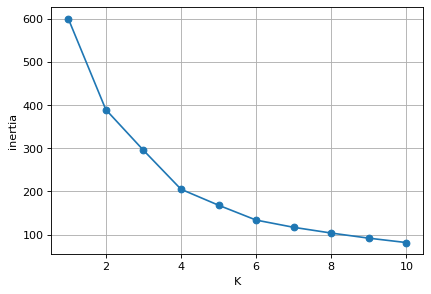

In [5]:
# Chạy riêng: thêm cột Age rồi chuẩn hóa lại cả 3 cột
from sklearn.metrics import silhouette_score

X3 = mall[['Age'] + cot].to_numpy(dtype=float)
X3_scaled = StandardScaler().fit_transform(X3)
ks, inertias_3 = ve_elbow(X3_scaled)
print('inertia khi có Age:', [round(v, 1) for v in inertias_3])

for k in [4, 5, 6]:
    s2 = silhouette_score(X_scaled, KMeans(n_clusters=k, n_init=10, random_state=3000).fit_predict(X_scaled))
    s3 = silhouette_score(X3_scaled, KMeans(n_clusters=k, n_init=10, random_state=3000).fit_predict(X3_scaled))
    print(f'K={k}: silhouette 2 cột = {s2:.3f}, silhouette 3 cột (có Age) = {s3:.3f}')

**Nộp kèm bài 1**

1. `K` bạn chọn là bao nhiêu? Elbow gãy ở đâu?
2. Mô tả từng cụm bằng thu nhập và điểm chi tiêu (cao / thấp). Cụm nào đáng ưu tiên cho khuyến mãi?
3. Nếu thêm cột `Age` vào `X` rồi chuẩn hóa lại, bạn có đổi `K` không?


In [6]:
# Bài 1
# 1. K = 5. Trên đồ thị elbow, inertia giảm rất nhanh từ K=1 đến K=5
#    (400 -> 271 -> 158 -> 109 -> 66), sau đó chỉ giảm chậm (55 ở K=6, 45 ở K=7) -> khuỷu ở K=5.
#    Silhouette cũng cao nhất ở K=5 (0.555, so với 0.494 ở K=4 và 0.538 ở K=6).
# 2. Năm cụm (thu nhập k$ / điểm chi tiêu, số khách):
#    - cụm 3: thu nhập cao (86.5) - chi tiêu cao (82.1), 39 khách: khách tốt nhất.
#    - cụm 1: thu nhập cao (88.2) - chi tiêu thấp (17.1), 35 khách: có tiền nhưng ít chi.
#    - cụm 4: thu nhập thấp (25.7) - chi tiêu cao (79.4), 22 khách.
#    - cụm 2: thu nhập thấp (26.3) - chi tiêu thấp (20.9), 23 khách.
#    - cụm 0: thu nhập trung bình (55.3) - chi tiêu trung bình (49.5), 81 khách: nhóm đông nhất.
#    Cụm đáng ưu tiên cho khuyến mãi là cụm 1: thu nhập cao nhưng điểm chi tiêu thấp nên còn
#    nhiều dư địa kích cầu. Cụm 3 là nhóm đã chi mạnh, nên giữ chân bằng ưu đãi thành viên.
# 3. Khi thêm Age (3 cột, chuẩn hóa lại), elbow không còn khuỷu rõ: inertia giảm đều
#    (600, 389, 296, 205, 168, 134, 117, ...). Silhouette thấp hơn hẳn (0.40 - 0.43 so với
#    0.49 - 0.56) và nhích lên cao nhất ở K=6 (0.427 so với 0.417 ở K=5). Vậy có thể đổi sang
#    K=6, nhưng chênh lệch rất nhỏ; cấu trúc 5 nhóm sắc nét chỉ có trên hai cột thu nhập - chi tiêu.

---

# Bài 2 — Phân nhóm quốc gia

Nguồn: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

167 nước, file `Country-data.csv`. Cột `country` là tên, không đưa vào `X`.

Các cột số: `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`.

`income` và `gdpp` lớn hơn `child_mort` rất nhiều. Bắt buộc `StandardScaler`. Chọn `K` bằng elbow (thường thử quanh 3). In trung bình `child_mort`, `income`, `life_expec`, `gdpp` theo cụm, và liệt kê khoảng 8 tên nước mỗi cụm.


               country  child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
0          Afghanistan        90.2     10.0    7.58     44.9    1610       9.44        56.2       5.82    553
1              Albania        16.6     28.0    6.55     48.6    9930       4.49        76.3       1.65   4090
2              Algeria        27.3     38.4    4.17     31.4   12900      16.10        76.5       2.89   4460
3               Angola       119.0     62.3    2.85     42.9    5900      22.40        60.1       6.16   3530
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100       1.44        76.8       2.13  12200
(167, 10)


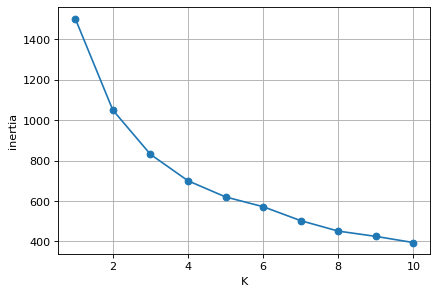

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [1503.0000000000002, 1050.2145582853307, 831.424435208687, 700.3917199643639, 620.4488115302205, 572.0890405033385, 503.0948550735081, 451.3236485291659, 425.20634399408505, 394.5676252504499])

In [7]:
country = pd.read_csv('data/Country-data.csv')
print(country.head())
print(country.shape)

cot_so = [c for c in country.columns if c != 'country']
# TODO: X từ cot_so, chuẩn hóa
X_scaled = StandardScaler().fit_transform(country[cot_so].to_numpy(dtype=float))

ve_elbow(X_scaled)

In [8]:
K = 3
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(country, labels, ['child_mort', 'income', 'life_expec', 'gdpp']))

for cum in np.unique(labels):
    ten = country.loc[labels == cum, 'country'].head(8).tolist()
    print(cum, ten)

     child_mort    income  life_expec      gdpp
cum                                            
0         21.93  12305.60       72.81   6486.45
1         92.96   3942.40       59.19   1922.38
2          5.00  45672.22       80.13  42494.44
0 ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh']
1 ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic']
2 ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic']


**Nộp kèm bài 2**

1. `K` bạn chọn? Cụm nào có `child_mort` cao và `gdpp` thấp?
2. Kể tên 3 nước thuộc cụm đó và 3 nước thuộc cụm có `gdpp` cao.
3. Vì sao không chuẩn hóa thì `income` và `gdpp` sẽ át các cột còn lại?


In [9]:
# Bài 2
# 1. K = 3. Inertia giảm 1503 -> 1050 -> 831 -> 700 -> 620: khuỷu khá mềm quanh K=3 - 4, chọn K=3
#    theo gợi ý và vì cho ba nhóm dễ diễn giải. Cụm có child_mort cao và gdpp thấp là cụm 1
#    (47 nước): child_mort trung bình 93.0, income 3942, life_expec 59.2, gdpp 1922.
#    Hai cụm còn lại: cụm 0 (84 nước, child_mort 21.9, gdpp 6486) và cụm 2 (36 nước,
#    child_mort 5.0, gdpp 42494).
# 2. Cụm 1 (child_mort cao, gdpp thấp): Afghanistan, Angola, Benin.
#    Cụm 2 (gdpp cao): Australia, Austria, Belgium.
# 3. KMeans dựa trên khoảng cách Euclid. income (609 - 125000) và gdpp (231 - 105000) có đơn vị
#    lớn hơn rất nhiều so với child_mort (2.6 - 208), total_fer (1.2 - 7.5) hay life_expec
#    (32 - 83). Không chuẩn hóa thì bình phương chênh lệch của income và gdpp lấn át, các cột
#    còn lại gần như không ảnh hưởng tới việc gán cụm.

---

# Bài 3 — Khách sỉ

Nguồn: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

440 khách hàng bán sỉ. File `Wholesale customers data.csv`.

Cột: `Channel`, `Region`, `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

`Channel` (1 = Horeca, 2 = Retail) và `Region` là mã nhóm, không phải số tiền. **Không** đưa hai cột này vào `X`. Gom cụm trên 6 cột chi tiêu, sau chuẩn hóa. Rồi dùng `pd.crosstab` để xem mỗi cụm nằm ở kênh nào.


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
(440, 8)


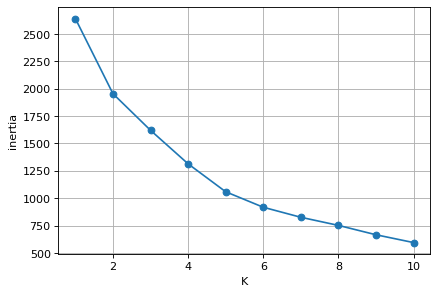

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [2639.9999999999977, 1954.1835647259281, 1619.952782172456, 1313.7580090341141, 1058.77125325701, 917.4454350272304, 825.8359775416376, 751.7362093470327, 666.2237996202148, 594.8556455931531])

In [10]:
import os
duong_dan_ws = 'data/Wholesale customers data.csv'
if not os.path.exists(duong_dan_ws):        # file tải về có thể tên Wholesale_customers_data.csv
    duong_dan_ws = 'data/Wholesale_customers_data.csv'
ws = pd.read_csv(duong_dan_ws)
print(ws.head())
print(ws.shape)

cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
# TODO: chuẩn hóa 6 cột chi tiêu
X_scaled = StandardScaler().fit_transform(ws[cot_chi].to_numpy(dtype=float))

ve_elbow(X_scaled)

In [11]:
K = 3
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(ws, labels, cot_chi))
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))

        Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
cum                                                                     
0    13618.91   3143.09   3881.77  3471.05            854.93     1192.14
1     5635.77  10034.58  15765.62  1457.59           6768.01     1737.61
2    25770.77  35160.38  41977.38  6844.54          19867.38     7880.31
Channel    1   2
cum             
0        280  38
1         16  93
2          2  11


**Nộp kèm bài 3**

1. `K` bạn chọn? Cụm nào chi mạnh cho `Grocery` và `Detergents_Paper`?
2. Cụm đó lệch về `Channel` nào trên bảng crosstab?
3. So với bài 1: vì sao bài 3 không vẽ một scatter là đủ để đọc cụm?


In [12]:
# Bài 3
# 1. K = 3. Elbow ở bộ này mềm (inertia 2640 -> 1954 -> 1620 -> 1314 -> 1059), chọn K=3 để ba cụm
#    còn dễ đọc. Cụm chi mạnh cho Grocery và Detergents_Paper:
#    - cụm 1 (109 khách): Grocery 15766, Detergents_Paper 6768, Milk 10035 cao, Fresh thấp (5636).
#      Đây là cụm có hồ sơ "Grocery + Detergents_Paper" đặc trưng nhất.
#    - cụm 2 (chỉ 13 khách): Grocery 41977, Detergents_Paper 19867 và cao ở mọi mặt hàng khác.
#      Đây là nhóm khách chi cực lớn.
#    Cụm 0 (318 khách) chi thấp hơn nhiều, nổi bật ở Fresh (13619).
# 2. Cụm 1 lệch về Channel 2 (Retail): 93 Retail so với 16 Horeca. Cụm 2 cũng lệch Retail
#    (11 so với 2). Cụm 0 lệch về Channel 1 (Horeca): 280 Horeca so với 38 Retail.
# 3. Bài 1 chỉ có 2 chiều nên một scatter thu nhập - chi tiêu thể hiện đủ dữ liệu. Bài 3 có
#    6 chiều chi tiêu, một scatter 2D chỉ cho thấy 2 chiều tại một thời điểm (cần tới 15 cặp
#    cột). Vì vậy phải đọc cụm qua bảng trung bình theo cụm và crosstab với Channel.